In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import kmedoids
import time
import geopandas as gpd
import shapefile
import random
import matplotlib.pyplot as plt
from pulp import *
from shapely.geometry import Point, LineString, Polygon
import time
import pickle
from arcgis import GIS
from arcgis.features import GeoAccessor
import geopandas
import copy
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from matplotlib.backends.backend_pdf import PdfPages

from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.cluster import cluster_visualizer
from pyclustering.utils import read_sample
from pyclustering.samples.definitions import FCPS_SAMPLES
from pyclustering.utils import calculate_distance_matrix

from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

# Real Case Study 1: Optimizing Zero-emission Refueling Station Locations in CA


For thiscase study, the data and optimization methodology present in https://doi.org/10.1016/j.trip.2025.101654 is used. This case performs a large-scale zero-emission refueling station site placement optimization for California’s freight network using a k-medoids-based clustering algorithm. The study seeks to identify the set of kn = 500 stations selected from a set of M = 3,497 candidate sites across California which, together, minimize freight diversion.  Here, we expand on this and seek examine whether Like the motivating example, hubness would be appropriate to consider because we would still want to maximize the functionality of the system should the project be terminated early. To see whether hubness emerges in thisIn this caseTo do this, the optimization is run 500 times, selecting between k = 1 and k = 500 stations.

Here we examine the results of the optimization in three primary ways:

    A. Optimization Results: visualize just the results of the optimization.
       - Optimization Cost Function vs k
       - Unserved Demand Sites vs k
    B. Histogram of n(tracts) vs Hubness: To see whether the optimization is selecting the greedy solution
    C. Comparing the Optimality of Selected Stations: Compares how objective function quantity varies as a function of k in the three cases:
        - The individually optimal strategy for each k aka 'Optimal solution for each number'
        - Selecting the k highest hubness sites aka 'Adding stations in order of hubness'
        - Randomly selecting from the 500 optimal

# I. Open Data

Note: here that the optimization is performed using code not included in this repository, as it uses proprietary data. Therefore, we start from the saved optimization results of selecting between k = 1 to k = 500 stations and show how hubness and the alternative strategies are calculated and compared.

In [3]:
# input and output locations
input_path = '../data/optimization_run_results/'
formatted_data_path = '../data/formatted_data/'
output_path = '../figures/'

# weights (fuel utilized as proxy for demand) 
weights_file_name = 'weights_df_28-02-23.csv'

# saved optimization results files
happiness_file = 'greedy_multiplication_15-03-2023_unhappiness.pkl' 
medoids_file = 'greedy_multiplication_15-03-2023_medoids.pkl' 
distance_matrix_file = 'greedy_multiplication_15-03-2023_dist_matrix.pkl'

# saved geodataframe
dataframe_file = 'gdf.pkl'

In [4]:
# open saved geodataframe file
df_dict = pd.read_pickle(input_path + dataframe_file)

gdf_la_dist = df_dict['gdf_la_dist']
census_gdf = df_dict['census_gdf'] # ca census tracts

In [5]:
with open(input_path + happiness_file, "rb") as pickle_file:
    happiness = pickle.load(pickle_file)
    
with open(input_path + medoids_file, "rb") as pickle_file:
    medoids = pickle.load(pickle_file)
    
with open(input_path + distance_matrix_file, "rb") as pickle_file:
    distance_matrix = pickle.load(pickle_file)

In [6]:
df_la_weights = pd.read_csv(formatted_data_path + weights_file_name)
weights = df_la_weights['fuel_consumption'].values.reshape(-1, 1)

In [7]:
df_la_weights = df_la_weights.merge(census_gdf, left_on = 'id', right_on = 'id', how= 'inner')

In [8]:
df_la_weights

,id,fuel_consumption,geometry,name,centroid
0,6.001400e+09,0.223727,"POLYGON ((-122.26563 37.83764, -122.26556 37.8...",4003,POINT (-122.25444020679815 37.84059704130319)
1,6.001401e+09,0.406857,"POLYGON ((-122.27802 37.84738, -122.27800 37.8...",4007,POINT (-122.27235288867247 37.84176679571366)
2,6.001401e+09,0.036777,"POLYGON ((-122.28558 37.83978, -122.28475 37.8...",4009,POINT (-122.28026458554268 37.83949120831866)
3,6.001401e+09,0.621769,"POLYGON ((-122.27871 37.82715, -122.27858 37.8...",4010,POINT (-122.2719012900836 37.83122553912201)
4,6.001401e+09,0.410939,"POLYGON ((-122.26855 37.82453, -122.26848 37.8...",4011,POINT (-122.26385773281358 37.83050136887572)
...,...,...,...,...,...
4799,6.115040e+09,0.771243,"POLYGON ((-121.56311 39.11310, -121.56286 39.1...",405,POINT (-121.55356967768499 39.100375904164544)
4800,6.115041e+09,0.925416,"POLYGON ((-121.56138 39.07756, -121.56137 39.0...",406,POINT (-121.54687995335732 39.084132903822116)
4801,6.115041e+09,4.605989,"POLYGON ((-121.61025 39.05691, -121.61021 39.0...",407,POINT (-121.55340304157853 39.01732072144869)
4802,6.115041e+09,2.554183,"POLYGON ((-121.51552 39.03064, -121.51532 39.0...",408,POINT (-121.43232871955037 39.03896676652808)


In [9]:
df_dict_a = gdf_la_dist.merge(df_la_weights, left_on = 'geometry', right_on = 'geometry', how= 'left')


In [10]:
travel_times = (distance_matrix.T/df_dict_a['fuel_consumption'].values).T
travel_times

array([[1.99999998e+00, 4.99999989e+00, 6.99999974e+00, ...,
        4.46972477e+10, 4.46972477e+10, 4.46972477e+10],
       [2.00000005e+00, 2.49999995e+00, 0.00000000e+00, ...,
        2.45786330e+10, 2.45786330e+10, 2.45786330e+10],
       [3.00000002e+00, 3.00000002e+00, 1.00000004e+00, ...,
        1.60831469e+10, 1.60831469e+10, 1.60831469e+10],
       ...,
       [1.43999997e+03, 1.43999997e+03, 1.43999997e+03, ...,
        5.19252336e+10, 5.19252336e+10, 5.19252336e+10],
       [1.44000003e+03, 1.44000003e+03, 1.44000003e+03, ...,
        4.70799271e+09, 4.70799271e+09, 4.70799271e+09],
       [1.44000002e+03, 1.44000002e+03, 1.44000002e+03, ...,
        6.84376925e+10, 6.84376925e+10, 6.84376925e+10]])

# II. Plots

### A. Optimization Results

First, we will visualize just the results of the optimization.

Here, we call the optimization cost function 'unhappiness' the quantity is actually demand weighted travel-time \[gallon minutes\].

In [11]:
num_stations = []
happiness_values = []

for x_val in happiness.keys():
    num_stations.append(x_val)
    happiness_values.append(happiness[x_val])
    

#### i. Demand Weighted Travel Time aka cost function of the optimization as a function of number of selected sites

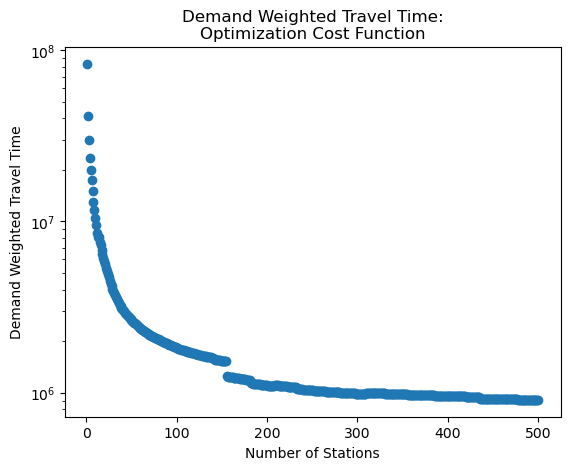

In [12]:
fig = plt.figure()

plt.yscale("log")
plt.scatter(num_stations, happiness_values)

plt.xlabel('Number of Stations')
plt.ylabel('Demand Weighted Travel Time')
plt.title('Demand Weighted Travel Time:\nOptimization Cost Function');

plt.savefig(output_path + 'unhappiness_distribution.png')

In [13]:
happiness_values[-1]

907509.6210832668

#### ii. Number of Demand with 'Unreasonable' Drives - Unserved demand sites

In the optimization, pair-wise census tracts with an uncalculatable travel time have their time set to 1 day in minutes. This was a large number meant to drive the optimization toward 'full coverage' as quickly as possible. See the optimization paper for more details. Here we look for the number of tracts which have this value as the travel time to get an idea of how many tracts are left unserved.

In [14]:
number_stations = []
number_unserved = []

for n_stations in range(1,len(medoids)+1):
    number_stations.append(len(medoids[n_stations]))

    # Find the unhappiness associated with top N stations based on hubness
    n_unserved = 0
    for x in range(len(distance_matrix)):
        min_station_value = np.max(distance_matrix[x,0:2400])
        served = False
                                   
        for included_station in medoids[n_stations]:
            if distance_matrix[x,included_station] < min_station_value:
                served = True
                break
                
        if served == False:
            n_unserved += 1
            
    number_unserved.append(n_unserved)

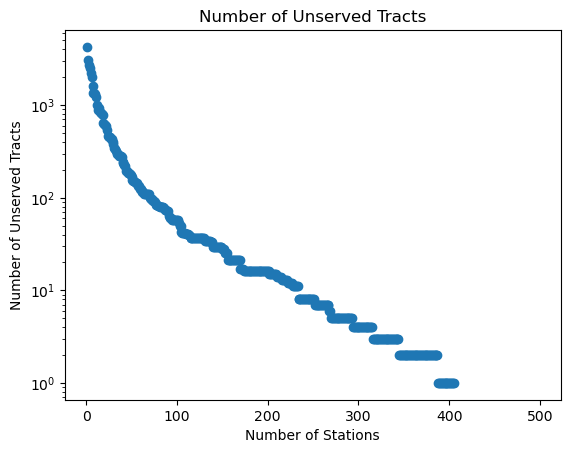

In [15]:
fig = plt.figure()

plt.scatter(number_stations, number_unserved)
plt.yscale("log")

plt.xlabel('Number of Stations')
plt.ylabel('Number of Unserved Tracts')
plt.title('Number of Unserved Tracts');

plt.savefig(output_path + 'unserved_distribution.png')

### B. Distribution of Hubness

This plot is meant to check how many tacts have each hubness value. The reason for this is that if the optimization is simply using a greedy selections, we would expect this to be completely flat with each tract having a unique hubness value between 1 and 500. It should be noted that while we see that this is not completely flat, it is very close. This means that the optimization is not doing much more than selecting the greedy solution. Future efforts could compare different methods of performing the optimization to see if this could be improved.

In [16]:
combined_selected = []

for key in medoids.keys():
    combined_selected.extend(medoids[key])
    
hubness_values, hubness_counts = np.unique(combined_selected, return_counts=True)

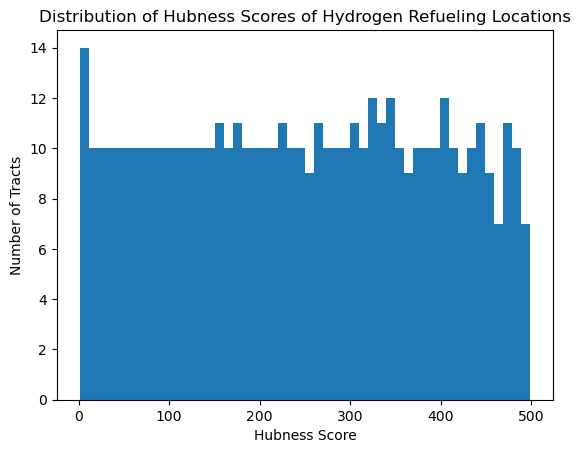

In [17]:
fig = plt.figure()

# We can set the number of bins with the *bins* keyword argument.
plt.hist(hubness_counts, bins=50);

plt.xlabel('Hubness Score')
plt.ylabel('Number of Tracts')
plt.title('Distribution of Hubness Scores of Hydrogen Refueling Locations');

plt.savefig(output_path + 'hubness_distribution.png')

### C. Optimality of Selected Stations

The objective function of this optimization seeks to minimize the demand weighted travel time from census tracts with truck traffic to the nearest selected candidate refueling locations. Here we shows how this quantity varies as a function of k in the three cases: 
- The individually optimal strategy for each k aka 'Optimal solution for each number'
- Selecting the k highest hubness sites aka 'Adding stations in order of hubness'
- Randomly selecting from the 500 optimal

We chose these to compare how the k highest hubness sites compares to the 'state of the art' individual answers. We expect that the individual will do better as the hubness solution has additional, practical contraints added (each set must be inclusive of the previous set) and seeks to therefore co-optimize across the 500 solutions. We chose to compare to random selection as well as this is meant to simulate what may happen if no organized strategy is used. This is the case in many such mega-projects and therefore simulates the current state of practice.

In [18]:
## Precalculate Some Values

selected_500 = np.array(medoids[500])
hubess_of_500 = []

for selected in selected_500:
    selected_index = list(hubness_values).index(selected)
    hubess_of_500.append(hubness_counts[selected_index])
    
sorted_hubness_of_500 = np.unique(np.array(hubess_of_500))[::-1]
descending_hubness_values = np.unique(np.array(hubness_counts))[::-1]

In [19]:
def calc_unhappiness_and_unserved(distance_matrix, included_stations):
    total_unhappiness = 0
    num_unserved = 0
    blocks_travel_times = []
    worst_case_scenario = 0
    cluster_num_included = {}
    cluster_fuel_demand = {}
    
    
    for x in range(len(distance_matrix)): #3498):#
        served = False
        served_num = 0
        min_station_value = np.max(distance_matrix[x,0:3498])#2400])
        block_travel_time = 0
            
        for included_station in included_stations:
            # Check if station is within 'reasonable' distance
            if distance_matrix[x,included_station] < min_station_value:
                min_station_value = distance_matrix[x,included_station]
                block_travel_time =  travel_times[x,included_station] #distance_matrix[x,included_station]/ np.sum(df_dict_a['fuel_consumption']) #travel_times[x,included_station]
                served = True
                served_num = included_station
        blocks_travel_times.append(block_travel_time)
            
        # Worst Case Travel Time
        if np.round(travel_times[x,served_num]) < 1440 and travel_times[x,served_num] > worst_case_scenario:
            worst_case_scenario = travel_times[x,served_num]

        # Cluster num included and demanded
        if served_num not in list(cluster_num_included.keys()):
            cluster_num_included.update({served_num: 1})
            if travel_times[x,served_num] != 0:
                cluster_fuel_demand.update({served_num: distance_matrix[x,served_num]/ travel_times[x,served_num]})
            else:
                cluster_fuel_demand.update({served_num: distance_matrix[x,served_num]})
        else:
            cluster_num_included[served_num] += 1
            if travel_times[x,served_num] != 0:
                cluster_fuel_demand[served_num] += distance_matrix[x,served_num]/ travel_times[x,served_num]
            else:
                cluster_fuel_demand[served_num] += distance_matrix[x,served_num]
        total_unhappiness = total_unhappiness + min_station_value
        
        if served == False:
            num_unserved += 1
            
    return total_unhappiness, num_unserved, worst_case_scenario, cluster_num_included, cluster_fuel_demand, np.mean(blocks_travel_times)

In [20]:
number_stations = []
top_n_hubness = []
top_n_hubness_avg_travel_time = []
top_n_hubness_unserved = []
top_n_hubness_worst_case = []
top_n_hubness_num_included = {}
top_n_hubness_fuel_demand = {}

randomly_selected_from_500 = []
randomly_selected_from_500_avg_travel_time = []
randomly_selected_from_500_unserved = []
randomly_selected_from_500_worst_case = []
randomly_selected_from_500_num_included = {}
randomly_selected_from_500_fuel_demand = {}

ordered_selected_from_500 = []
ordered_selected_from_500_avg_travel_time = []
ordered_selected_from_500_unserved = []
ordered_selected_from_500_worst_case = []
ordered_selected_from_500_num_included = {}
ordered_selected_from_500_fuel_demand = {}

for n_stations in tqdm(range(1, 499), desc="Processed Stations"):    
    number_stations.append(n_stations)

    # Find the unhappiness associated with top N stations based on hubness
    included_stations = []
    hubness_index = 0
    while len(included_stations) < n_stations:
        included_stations.extend(hubness_values[hubness_counts == descending_hubness_values[hubness_index]])
        hubness_index += 1
        
    if len(included_stations) > n_stations:
        included_stations = included_stations[0:n_stations]

    total_unhappiness, num_unserved, worst_case_scenario, cluster_num_included, cluster_fuel_demand, avg_travel_time1 = calc_unhappiness_and_unserved(distance_matrix, included_stations)

    top_n_hubness.append(total_unhappiness)
    top_n_hubness_avg_travel_time.append(avg_travel_time1)
    top_n_hubness_unserved.append(num_unserved)
    top_n_hubness_worst_case.append(worst_case_scenario)
    top_n_hubness_num_included.update({n_stations: cluster_num_included})
    top_n_hubness_fuel_demand.update({n_stations: cluster_fuel_demand})
    
    # Find the unhappiness associated with adding a random station from set of final 500
    included_stations = []
    included_indicies = random.sample(range(0, len(selected_500)), n_stations)

    for index_num in range(0,len(included_indicies)):
        included_stations.append(selected_500[included_indicies[index_num]])
        
    total_unhappiness, num_unserved, worst_case_scenario, cluster_num_included, cluster_fuel_demand, avg_travel_time2 = calc_unhappiness_and_unserved(distance_matrix, included_stations)
    #print(avg_travel_time1, avg_travel_time2)
    randomly_selected_from_500.append(total_unhappiness)
    randomly_selected_from_500_avg_travel_time.append(avg_travel_time2)
    randomly_selected_from_500_unserved.append(num_unserved)
    randomly_selected_from_500_worst_case.append(worst_case_scenario)
    randomly_selected_from_500_num_included.update({n_stations: cluster_num_included})
    randomly_selected_from_500_fuel_demand.update({n_stations: cluster_fuel_demand})
    
    # Adding stations from top 500, ordered by hubness
    included_stations = []
    hubness_index = 0
    while len(included_stations) < n_stations:
        included_stations.extend(selected_500[hubess_of_500 == sorted_hubness_of_500[hubness_index]])
        hubness_index += 1
        
    if len(included_stations) > n_stations:
        included_stations = included_stations[0:n_stations]
    
    total_unhappiness, num_unserved, worst_case_scenario, cluster_num_included, cluster_fuel_demand, avg_travel_time = calc_unhappiness_and_unserved(distance_matrix, included_stations)
    ordered_selected_from_500.append(total_unhappiness)
    ordered_selected_from_500_avg_travel_time.append(avg_travel_time)
    ordered_selected_from_500_unserved.append(num_unserved)
    ordered_selected_from_500_worst_case.append(worst_case_scenario)
    ordered_selected_from_500_num_included.update({n_stations: cluster_num_included})
    ordered_selected_from_500_fuel_demand.update({n_stations: cluster_fuel_demand})
    

Processed Stations:   0%|          | 0/498 [00:00<?, ?it/s]

#### i. Mean Travel Time

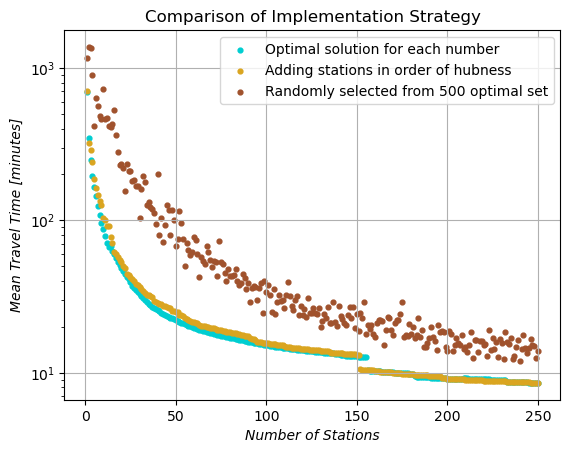

In [21]:
x_plot_range = [0,250]

plt.scatter(num_stations[x_plot_range[0]:x_plot_range[1]], happiness_values[x_plot_range[0]:x_plot_range[1]]/ np.sum(df_dict_a['fuel_consumption']), color = 'darkturquoise', label = 'Optimal solution for each number',s=12)
plt.scatter(number_stations[x_plot_range[0]:x_plot_range[1]], top_n_hubness[x_plot_range[0]:x_plot_range[1]]/ np.sum(df_dict_a['fuel_consumption']), color = 'goldenrod', label = 'Adding stations in order of hubness',s=12)
plt.scatter(number_stations[x_plot_range[0]:x_plot_range[1]], randomly_selected_from_500[x_plot_range[0]:x_plot_range[1]]/ np.sum(df_dict_a['fuel_consumption']), color = 'sienna', label = 'Randomly selected from 500 optimal set',s=12)
#plt.scatter(number_stations[x_plot_range[0]:x_plot_range[1]], ordered_selected_from_500[x_plot_range[0]:x_plot_range[1]], color = 'k', label = 'Add N stations in hubness order from 500 optimal set')

xlab = plt.xlabel('Number of Stations')
ylab = plt.ylabel('Mean Travel Time [minutes]')
plt.title('Comparison of Implementation Strategy');
plt.legend()
#plt.xlim([-5, 200])
plt.yscale("log")


xlab.set_style('italic')
xlab.set_size(10)
ylab.set_style('italic')
ylab.set_size(10)

plt.grid()
plt.savefig(output_path + 'avg_travel_time_optimality_distribution_head_nohubness_0-250_b.png')


### ii. Cost Function of Optimization - Demand Weighted Travel Time 

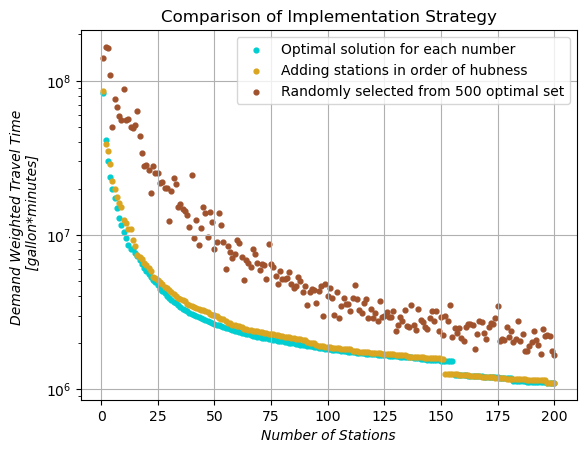

In [22]:
fig = plt.figure()

x_plot_range = [0,200]

plt.scatter(num_stations[x_plot_range[0]:x_plot_range[1]], happiness_values[x_plot_range[0]:x_plot_range[1]], color = 'darkturquoise', label = 'Optimal solution for each number',s=12)
plt.scatter(number_stations[x_plot_range[0]:x_plot_range[1]], top_n_hubness[x_plot_range[0]:x_plot_range[1]], color = 'goldenrod', label = 'Adding stations in order of hubness',s=12)
plt.scatter(number_stations[x_plot_range[0]:x_plot_range[1]], randomly_selected_from_500[x_plot_range[0]:x_plot_range[1]], color = 'sienna', label = 'Randomly selected from 500 optimal set',s=12)
#plt.scatter(number_stations[x_plot_range[0]:x_plot_range[1]], ordered_selected_from_500[x_plot_range[0]:x_plot_range[1]], color = 'k', label = 'Add N stations in hubness order from 500 optimal set')

xlab = plt.xlabel('Number of Stations')
ylab = plt.ylabel('Demand Weighted Travel Time \n [gallon*minutes]')
plt.title('Comparison of Implementation Strategy');
plt.legend()
#plt.xlim([-5, 200])
plt.yscale("log")

xlab.set_style('italic')
xlab.set_size(10)
ylab.set_style('italic')
ylab.set_size(10)

plt.grid()

plt.savefig(output_path + 'unhappiness_distributions_optimality_distribution_head.png')
